# Práctica: Segmentación de clientes (Análisis factorial + clustering)

**Curso:** Analítica del Marketing / Inteligencia de Negocios  
**Modalidad:** Trabajo por equipos  
**Entrega:** Libreta de Jupyter con celdas de texto y código (comentado)

---

## Objetivo
Aplicar técnicas de análisis multivariado para **identificar y caracterizar segmentos de clientes** a partir de la importancia que asignan a distintos atributos en la elección de un supermercado, integrando:

- Preprocesamiento (calidad de datos y estandarización)
- **Análisis factorial** (reducción de dimensionalidad + interpretación)
- **Clustering** (segmentación + justificación del número de grupos)
- Interpretación de segmentos e implicaciones de marketing

## Contexto del instrumento
Cada variable corresponde a un atributo evaluado en escala Likert de **1 (nada importante) a 7 (muy importante)** (v1–v26).

## Instrucciones generales
1. Tu libreta debe incluir **explicaciones en texto** (Markdown) y **código reproducible**.
2. Toda decisión importante debe estar **justificada** (no basta con “porque sí”).
3. Incluye **visualizaciones** cuando aporten claridad (correlaciones, scree plot, codo, silueta, perfiles por segmento).
4. Si tu código requiere aleatoriedad (p. ej., k-means), fija una **semilla** para reproducibilidad.

---
# 1. Carga y exploración inicial
En esta sección debes:
- Cargar el dataset.
- Inspeccionar estructura (filas, columnas, nombres de variables).
- Verificar tipos de datos.
- Revisar valores faltantes y rangos (esperado: 1–7).
- Presentar estadísticos descriptivos básicos (media, desviación estándar, mínimo, máximo).

**Entrega mínima:**
- Tabla/resumen de valores faltantes.
- Tabla de descriptivos.
- Comentario breve de hallazgos (p. ej., variables con varianza alta/baja, posibles outliers, etc.).

In [ ]:
# TODO: Importa librerías, carga el archivo y realiza la exploración inicial.
# Sugerencia: pandas, numpy, matplotlib, seaborn (opcional), sklearn

##Importando datos

In [ ]:
import pandas as pd

supermarket = pd.read_csv('supermarket.csv')
supermarket.head()

,income,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v26,v27,v28,v29,v30,v31,v32,v33,v34,v35
0,1.0,1.0,7.0,7.0,5.0,7.0,7.0,7.0,7.0,7.0,...,1.0,5.0,1.0,5.0,7.0,7.0,5.0,1.0,7.0,7.0
1,1.0,2.0,5.0,5.0,7.0,7.0,7.0,4.0,4.0,4.0,...,7.0,2.0,1.0,7.0,7.0,7.0,7.0,1.0,6.0,7.0
2,1.0,4.0,7.0,4.0,7.0,7.0,7.0,7.0,7.0,4.0,...,7.0,6.0,1.0,5.0,7.0,7.0,7.0,1.0,6.0,7.0
3,1.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,...,7.0,7.0,1.0,1.0,7.0,1.0,7.0,1.0,7.0,7.0
4,1.0,7.0,7.0,7.0,7.0,7.0,5.0,6.0,7.0,6.0,...,1.0,7.0,1.0,1.0,7.0,7.0,1.0,1.0,7.0,5.0


In [ ]:
supermarket = supermarket.drop(columns=['income'])

Se elimina la columna income para trabaar solo con las preguntas

##Inspeccion

In [ ]:
supermarket.columns.duplicated().sum()

np.int64(0)

In [ ]:
#resumen
supermarket.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 35 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   v1      60 non-null     float64
 1   v2      60 non-null     float64
 2   v3      60 non-null     float64
 3   v4      60 non-null     float64
 4   v5      60 non-null     float64
 5   v6      60 non-null     float64
 6   v7      60 non-null     float64
 7   v8      60 non-null     float64
 8   v9      60 non-null     float64
 9   v10     60 non-null     float64
 10  v11     60 non-null     float64
 11  v12     60 non-null     float64
 12  v13     60 non-null     float64
 13  v14     60 non-null     float64
 14  v15     60 non-null     float64
 15  v16     60 non-null     float64
 16  v17     60 non-null     float64
 17  v18     60 non-null     float64
 18  v19     60 non-null     float64
 19  v20     60 non-null     float64
 20  v21     60 non-null     float64
 21  v22     60 non-null     float64
 22  v23 

In [ ]:
#contar numero de filas
len(supermarket)

60

In [ ]:
supermarket.describe()


,v1,v2,v3,v4,v5,v6,v7,v8,v9,v10,...,v26,v27,v28,v29,v30,v31,v32,v33,v34,v35
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,...,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,5.766667,6.233333,5.816667,5.866667,6.116667,6.233333,6.066667,6.583333,6.000000,6.133333,...,3.933333,6.033333,2.066667,4.633333,6.333333,5.683333,3.466667,1.350000,5.933333,6.333333
std,1.942972,1.169770,1.308274,1.407807,1.403285,1.110301,1.363777,0.925929,1.134961,1.199812,...,2.615901,1.206854,1.894387,2.291966,1.052304,1.935324,2.487028,1.070799,1.655670,1.174109
min,1.000000,3.000000,1.000000,1.000000,2.000000,3.000000,1.000000,3.000000,3.000000,2.000000,...,1.000000,2.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,5.000000,6.000000,5.000000,5.000000,6.000000,6.000000,5.000000,7.000000,5.000000,5.000000,...,1.000000,5.000000,1.000000,3.000000,6.000000,5.000000,1.000000,1.000000,5.000000,6.000000
50%,7.000000,7.000000,6.000000,6.000000,7.000000,7.000000,7.000000,7.000000,6.000000,7.000000,...,4.000000,6.500000,1.000000,5.000000,7.000000,7.000000,3.000000,1.000000,7.000000,7.000000
75%,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,...,7.000000,7.000000,3.000000,7.000000,7.000000,7.000000,7.000000,1.000000,7.000000,7.000000
max,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,...,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000


In [ ]:
#rangos anormales
(supermarket < 1).sum().sum()
(supermarket > 7).sum().sum()

np.int64(0)

In [ ]:
#datos nulos
supermarket.isnull().sum()

,0
v1,0
v2,0
v3,0
v4,0
v5,0
v6,0
v7,0
v8,0
v9,0
v10,0


In [ ]:
#datos faltantes
supermarket.isna().sum()

,0
v1,0
v2,0
v3,0
v4,0
v5,0
v6,0
v7,0
v8,0
v9,0
v10,0


* No se encontraron filas con datos nulos
* Datos de tipo Flotante


---
# 2. Preprocesamiento y estandarización
Aunque todas las variables están en la misma escala (1–7), **no asumas** que no se requiere estandarización.

En esta sección debes:
1. Explicar si procede estandarizar o no.
2. Justificar tu decisión con evidencia (por ejemplo: comparar desviaciones estándar entre variables).
3. Si estandarizas, explica el método (p. ej., z-score) y muestra una comparación breve **antes vs. después**.

**Entrega mínima:**
- Justificación en texto.
- Si aplica, código de estandarización y verificación.

In [ ]:
# TODO: Decide y aplica estandarización (si procede).
# Recomendación: sklearn.preprocessing.StandardScaler

In [ ]:
#checando desviacion estandar

supermarket.std()

,0
v1,1.942972
v2,1.169770
v3,1.308274
v4,1.407807
v5,1.403285
v6,1.110301
v7,1.363777
v8,0.925929
v9,1.134961
v10,1.199812


In [ ]:
supermarket.describe().T[['mean','std','min','max']]

,mean,std,min,max
v1,5.766667,1.942972,1.0,7.0
v2,6.233333,1.169770,3.0,7.0
v3,5.816667,1.308274,1.0,7.0
v4,5.866667,1.407807,1.0,7.0
v5,6.116667,1.403285,2.0,7.0
v6,6.233333,1.110301,3.0,7.0
v7,6.066667,1.363777,1.0,7.0
v8,6.583333,0.925929,3.0,7.0
v9,6.000000,1.134961,3.0,7.0
v10,6.133333,1.199812,2.0,7.0


In [ ]:
#desviaciones superiores a 1.75
supermarket.std() > 1.75

,0
v1,True
v2,False
v3,False
v4,False
v5,False
v6,False
v7,False
v8,False
v9,False
v10,False


###Al comparar loas desviaciones estandar nos damos cuenta que hay mucha disparidad entre la mayoria de preguntas, por ende se decide hacer una estandarizacion de esos valores utilizando standardscaler de sklearn

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(supermarket)

# Convertir nuevamente a DataFrame
df_scaled = pd.DataFrame(df_scaled, columns=supermarket.columns)

In [ ]:
df_scaled.describe().T[['mean','std','min','max']]

,mean,std,min,max
v1,-7.401487e-18,1.008439,-2.473989,0.640123
v2,-2.220446e-17,1.008439,-2.787402,0.660930
v3,1.665335e-16,1.008439,-3.712764,0.912132
v4,2.442491e-16,1.008439,-3.486086,0.811828
v5,3.460195e-16,1.008439,-2.958349,0.634787
v6,-1.221245e-16,1.008439,-2.936698,0.696331
v7,1.535809e-16,1.008439,-3.746525,0.690149
v8,3.256654e-16,1.008439,-3.902646,0.453796
v9,5.551115e-18,1.008439,-2.665570,0.888523
v10,-3.312165e-16,1.008439,-3.474057,0.728431


<Axes: >

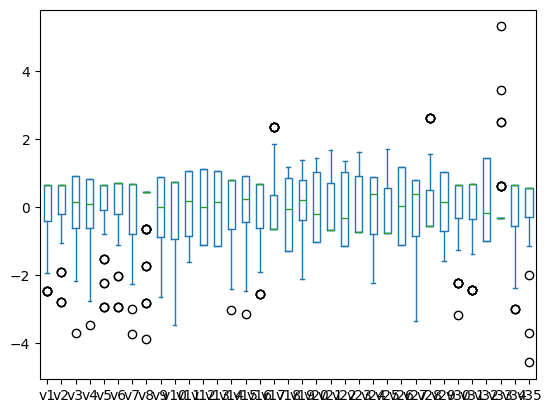

In [ ]:
df_scaled.plot.box()

###Se observa una reduccion cercana a 1 de la desviacion estandar y medias aproximadas a 0, lo cual sugiere una correcta estandarizacion

###Los valores mínimos y máximos representan la distancia en desviaciones estándar respecto a la media.

### Los valores negativos indican observaciones que se encuentran por debajo del promedio de la variable, mientras que los valores positivos indican observaciones por encima del promedio.

###Se observan algunos valores extremos (por ejemplo, cercanos a ±4), lo cual sugiere la presencia de observaciones relativamente alejadas del centro de la distribución, aunque esto es esperado al trabajar con datos estandarizados.

## Datos atípicos

Apliaremos un enfoque moderado y consideremos dato atípico a cualquiera cuyo valor absoluto sea mayor a 4 (desviaciones estándar de la media)

In [ ]:
outlier_data = df_scaled.abs() > 4
any_outlier = outlier_data.any(axis=1) #¿existe algún valor atípico en la fila?
any_outlier

,0
0,False
1,False
2,False
3,False
4,False
5,False
6,False
7,False
8,False
9,False


In [ ]:
sum(any_outlier)/len(any_outlier)*100

3.3333333333333335

Eliminamos los datos atipicos

In [ ]:
seg_dat_sub = df_scaled[~any_outlier.values]
seg_dat_sub.columns = supermarket.columns
seg_dat_sub.describe()

,v1,v2,v3,v4,v5,v6,v7,v8,v9,v10,...,v26,v27,v28,v29,v30,v31,v32,v33,v34,v35
count,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,5.800000e+01,58.000000,...,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000
mean,0.022670,0.036663,0.021707,0.033758,0.040061,0.038627,0.052696,0.059463,5.742533e-18,0.047338,...,-0.000886,0.029774,-0.007954,0.002023,0.011015,0.012278,-0.021439,-0.102295,0.040605,0.069107
std,0.988873,0.952518,0.977168,0.951483,0.943604,0.944090,0.891738,0.882166,1.012389e+00,0.910661,...,1.002835,0.963107,1.023823,1.005014,1.008318,1.004949,1.007733,0.733960,0.940823,0.820906
min,-2.473989,-2.787402,-3.712764,-3.486086,-2.958349,-2.936698,-3.007080,-2.813535,-2.665570e+00,-1.793062,...,-1.130810,-3.370225,-0.567819,-1.598625,-3.194383,-2.440343,-1.000183,-0.329617,-3.004805,-3.721889
25%,-0.268160,-0.201153,-0.629500,-0.620810,-0.083840,-0.211927,-0.788742,0.453796,-8.885233e-01,-0.742440,...,-1.130810,-0.863446,-0.567819,-0.718648,-0.319438,-0.356064,-1.000183,-0.329617,-0.568477,-0.286299
50%,0.640123,0.660930,0.141316,0.095509,0.634787,0.696331,0.690149,0.453796,0.000000e+00,0.728431,...,0.025700,0.389943,-0.567819,0.161329,0.638877,0.686075,-0.391963,-0.329617,0.649688,0.572598
75%,0.640123,0.660930,0.912132,0.811828,0.634787,0.696331,0.690149,0.453796,8.885233e-01,0.728431,...,1.182211,0.807740,0.496841,1.041306,0.638877,0.686075,1.331324,-0.329617,0.649688,0.572598
max,0.640123,0.660930,0.912132,0.811828,0.634787,0.696331,0.690149,0.453796,8.885233e-01,0.728431,...,1.182211,0.807740,2.626162,1.041306,0.638877,0.686075,1.432694,3.437436,0.649688,0.572598


In [ ]:
seg_dat_sub.columns.duplicated().sum()

np.int64(0)

In [ ]:
import numpy as np
np.linalg.det(seg_dat_sub.corr())

np.float64(5.30947939744823e-13)

<Axes: >

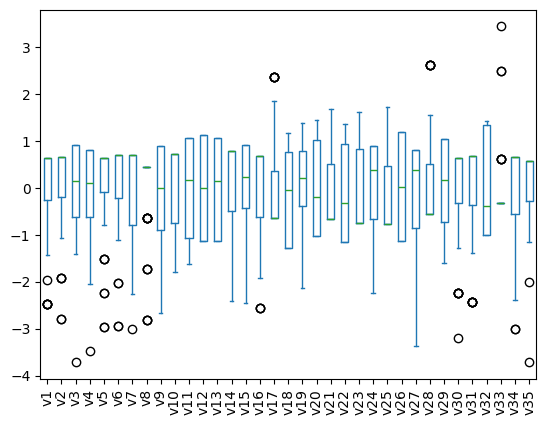

In [ ]:
seg_dat_sub.plot.box(rot=90)

Con el objetivo de evitar que valores extremos influyan en el análisis factorial y la formación de clusters, se procedió a excluir dichas observaciones para el análisis subsecuente.

---
# 3. Análisis factorial (reducción de dimensionalidad)
En esta sección debes demostrar que el análisis factorial es pertinente y luego interpretarlo.

## 3.1. Verificación de pertinencia
Incluye, como mínimo:


- **Prueba de esfericidad de Bartlett**.



#Prueba de esfericidad de Barlett
1. ¿Qué evalúa la prueba?
La prueba comprueba la hipótesis de que la matriz de correlación es una matriz identidad.
Matriz Identidad: Una matriz donde los elementos de la diagonal son 1 (correlación de la variable consigo misma) y todos los elementos fuera de la diagonal son 0 (no hay correlación entre variables distintas).
En resumen, evalúa si todas las variables están incorrelacionadas.
2. Hipótesis Nula (
): La matriz de correlación es una matriz identidad (las variables no están correlacionadas, no es idóneo el análisis factorial).
3. Hipótesis Alternativa (
): La matriz de correlación no es una matriz identidad (al menos algunas variables están correlacionadas, lo que permite el análisis factorial).

- Inspección de la **matriz de correlaciones** (o heatmap).

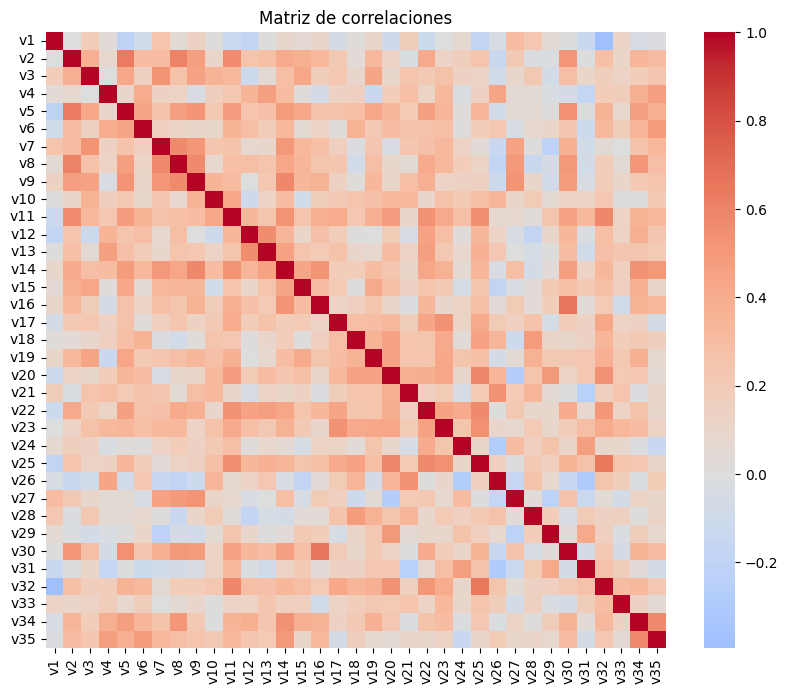

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = seg_dat_sub.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Matriz de correlaciones")
plt.show()

##ANALISIS DE HEATMAP Y MATRIZ DE CORRELACION
La diagonal principal muestra valores iguales a 1, correspondientes a la correlación perfecta de cada variable consigo misma, los cuales no se consideran para el análisis.

Se observan múltiples correlaciones moderadas entre diferentes variables, lo cual sugiere la existencia de dimensiones latentes comunes y respalda la aplicación del análisis factorial.

- **KMO**.

##KMO (Kaiser-Meyer-Olkin)

El KMO mide si las correlaciones parciales son pequeñas.

In [ ]:
pip install factor_analyzer

In [ ]:
len(seg_dat_sub)

58

In [ ]:
from factor_analyzer.factor_analyzer import calculate_kmo
kmo_all, kmo_model = calculate_kmo(seg_dat_sub)

print("KMO general:", kmo_model)

KMO general: 0.6055423735385556


/usr/local/lib/python3.12/dist-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


In [ ]:
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity

chi_square_value, p_value = calculate_bartlett_sphericity(seg_dat_sub)

print("Chi-cuadrado:", chi_square_value)
print("p-value:", p_value)

Chi-cuadrado: 1257.753002707221
p-value: 1.2899939178787573e-49


La muestra disponible fue de 60 observaciones para 35 variables (58 una vez obtenida la segmentacion), lo que representa una relación inferior a la recomendada en literatura (5:1). No obstante, dado que el KMO supera el umbral mínimo (0.50) y la prueba de Bartlett resultó significativa, se procede con cautela al análisis factorial exploratorio.

## 3.2. Selección del número de factores
Justifica el número de factores con criterios como:
- Eigenvalues (>1) (si aplica).
- **Scree plot**.
- Porcentaje de varianza explicada.

In [ ]:
from factor_analyzer import FactorAnalyzer

fa = FactorAnalyzer(rotation=None)
fa.fit(seg_dat_sub)

eigenvalues, vectors = fa.get_eigenvalues()

print(eigenvalues)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[8.70634092 3.72432653 2.76254909 2.56880291 1.81750292 1.53747089
 1.5122312  1.33523223 1.15326698 1.05983731 0.9419864  0.87908447
 0.78686727 0.70046971 0.68287299 0.58462235 0.52733143 0.44781744
 0.41193259 0.40101804 0.35515378 0.34374425 0.27060151 0.25714175
 0.2117451  0.18097973 0.15721956 0.15200251 0.13418445 0.10909645
 0.09497987 0.06704119 0.05437272 0.04119419 0.02897924]


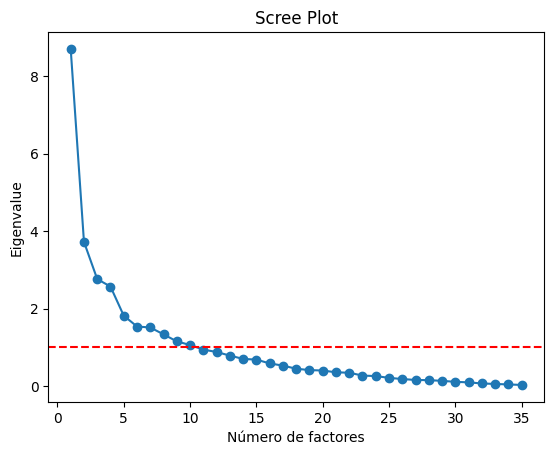

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(range(1, len(eigenvalues)+1), eigenvalues)
plt.plot(range(1, len(eigenvalues)+1), eigenvalues)
plt.axhline(y=1, color='r', linestyle='--')
plt.title('Scree Plot')
plt.xlabel('Número de factores')
plt.ylabel('Eigenvalue')
plt.show()

Analizando los resultados tenemos unos 10 factores que vienen del factoranalyzer. Sin embargo se haran mas pruebas para llegar a una cantidad razonable de factores debido al tamaño de la muestra



## 3.3. Ajuste del modelo factorial
- Ajusta el modelo factorial.
- Aplica una rotación (por ejemplo, **Varimax**).

## 3.4. Interpretación
- Reporta cargas factoriales (tabla).
- Identifica variables que cargan fuerte en cada factor.
- Asigna un **nombre conceptual** a cada factor.
- Explica qué representa cada factor en términos del comportamiento del consumidor.

**Entrega mínima:**
- Evidencia de KMO y Bartlett.
- Scree plot y decisión de # factores.
- Tabla de cargas con rotación.
- Interpretación escrita de factores.

In [ ]:
kmo_all, kmo_model = calculate_kmo(seg_dat_sub)

print("KMO por variable:")
print(kmo_all)

print("\nKMO global:")
print(kmo_model)

KMO por variable:
[0.33600186 0.54250193 0.67978423 0.46083575 0.64195143 0.77350272
 0.7309712  0.66716704 0.77051831 0.45419126 0.68321165 0.770558
 0.60969336 0.81271296 0.64735143 0.70577358 0.72399899 0.78346658
 0.58984075 0.76973648 0.36538679 0.6092611  0.59991434 0.31389624
 0.58704796 0.41376215 0.41338985 0.47457807 0.51329397 0.66779843
 0.44153971 0.64470915 0.35728441 0.63189987 0.71610031]

KMO global:
0.6055423735385556


/usr/local/lib/python3.12/dist-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


In [ ]:
fa = FactorAnalyzer(n_factors=5, rotation='varimax')
fa.fit(seg_dat_sub)

loadings = pd.DataFrame(fa.loadings_,
                        index=seg_dat_sub.columns)

print(loadings)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


            0         1         2         3         4
v1   0.032067 -0.219018  0.228141 -0.038868  0.331808
v2   0.668674  0.212406 -0.032985 -0.029539  0.105269
v3   0.493137 -0.052102  0.421803 -0.145627  0.177627
v4   0.084154  0.265792  0.103485  0.639297  0.046029
v5   0.696374  0.218005  0.156578  0.082365 -0.066875
v6   0.353653  0.155634  0.190107  0.417765 -0.170070
v7   0.536129  0.013542  0.177023  0.005820  0.512677
v8   0.633758  0.225172 -0.085862 -0.022647  0.383736
v9   0.600822  0.083705  0.230424 -0.091647  0.454136
v10  0.142818  0.176202  0.473845  0.046379  0.113722
v11  0.517707  0.511556  0.190962 -0.035445 -0.148922
v12  0.266832  0.546379 -0.330389  0.339517 -0.105280
v13  0.238884  0.506327 -0.060590  0.331188  0.053693
v14  0.696940  0.276658  0.081846  0.164636  0.110266
v15  0.544554  0.089606  0.127545 -0.136426 -0.108936
v16  0.521710  0.168227  0.008217 -0.007817  0.029542
v17  0.103486  0.532497  0.277782 -0.062997  0.096212
v18  0.070839  0.261507  0.5

In [ ]:
fa = FactorAnalyzer(n_factors=4, rotation='varimax')
fa.fit(seg_dat_sub)

loadings4 = pd.DataFrame(fa.loadings_,
                         index=seg_dat_sub.columns)

print(loadings4)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


            0         1         2         3
v1  -0.011165 -0.097804  0.001993  0.455447
v2   0.701097  0.092380 -0.032796  0.046096
v3   0.383063  0.228657 -0.103722  0.480146
v4   0.159905  0.160154  0.663185 -0.061290
v5   0.648096  0.290835  0.080020  0.051480
v6   0.296911  0.276318  0.405585 -0.044997
v7   0.570442 -0.051659  0.054185  0.502508
v8   0.744949 -0.052602 -0.001114  0.179029
v9   0.626131  0.061975 -0.038548  0.491738
v10  0.120079  0.391929  0.114737  0.328894
v11  0.559710  0.521280 -0.012858 -0.100220
v12  0.456122  0.113374  0.317149 -0.483470
v13  0.402856  0.211372  0.351813 -0.194511
v14  0.727877  0.195285  0.173106  0.083432
v15  0.463621  0.222680 -0.141064  0.061306
v16  0.528477  0.118587 -0.012965  0.022715
v17  0.231059  0.462098  0.018123  0.060579
v18 -0.007746  0.609891  0.191401  0.082816
v19  0.310674  0.542635 -0.215511  0.283743
v20  0.109652  0.771351  0.117275 -0.121085
v21 -0.033845  0.379193  0.424408  0.490464
v22  0.559620  0.416110  0.00552

In [ ]:
fa = FactorAnalyzer(n_factors=3, rotation='varimax')
fa.fit(seg_dat_sub)

loadings3 = pd.DataFrame(fa.loadings_,
                         index=seg_dat_sub.columns)

print(loadings3)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


            0         1         2
v1   0.127483 -0.125228 -0.102211
v2   0.675070  0.123861  0.126272
v3   0.501036  0.218729 -0.067495
v4   0.022324  0.051880  0.712937
v5   0.601342  0.295390  0.252034
v6   0.190746  0.215382  0.509067
v7   0.669954 -0.062975  0.066933
v8   0.762276 -0.029966  0.113553
v9   0.732991  0.062800  0.008109
v10  0.177748  0.338765  0.122601
v11  0.471096  0.545494  0.205868
v12  0.225583  0.122098  0.472970
v13  0.256589  0.182973  0.483320
v14  0.675931  0.187462  0.339779
v15  0.465721  0.259235 -0.011756
v16  0.502611  0.140645  0.112729
v17  0.211655  0.461439  0.114719
v18 -0.038515  0.553533  0.254090
v19  0.384029  0.558434 -0.112368
v20  0.009591  0.757445  0.267935
v21  0.048958  0.250014  0.307075
v22  0.475030  0.444024  0.197607
v23  0.266486  0.572095  0.202222
v24  0.230398  0.315779 -0.304524
v25  0.190866  0.680442  0.249796
v26 -0.338443  0.218790  0.614768
v27  0.488998 -0.172480 -0.070840
v28 -0.060823  0.424078 -0.023515
v29 -0.072135 

Debido al tamaño de la muestra el criterio de 10 factores que nos daba el criterio de kaiser fue sustituido a 3 factores, esta desicion se tomo luego de estar comparando soluciones desde los 5 factores, hasta llegar a los 3 factores finales

---
# 4. Segmentación (clustering) usando factores
En esta sección debes segmentar clientes usando los **scores factoriales** como entrada.

## 4.1. Preparación
- Obtén los **factor scores** para cada observación.
- Verifica su escala (si estandarizaste antes y/o si los scores lo requieren).

In [ ]:
fa = FactorAnalyzer(n_factors=3, rotation='varimax')
fa.fit(seg_dat_sub)

factor_scores = fa.transform(seg_dat_sub)

import pandas as pd
factor_scores = pd.DataFrame(factor_scores, columns=['F1','F2','F3'])

factor_scores.head()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,F1,F2,F3
0,1.225836,0.048444,-0.546748
1,-1.910681,1.098654,1.654203
2,-0.177796,1.524867,1.448739
3,0.575990,0.495279,1.717356
4,0.913582,0.519595,-0.194274


In [ ]:
factor_scores.describe()

,F1,F2,F3
count,5.800000e+01,5.800000e+01,5.800000e+01
mean,1.914178e-17,8.422382e-17,-3.828355e-17
std,9.659942e-01,9.497044e-01,9.263607e-01
min,-2.987114e+00,-2.074808e+00,-3.317240e+00
25%,-4.607546e-01,-5.737418e-01,-6.314370e-01
50%,1.482395e-01,-1.296574e-01,-8.126924e-02
75%,7.091575e-01,5.135376e-01,6.542918e-01
max,1.250609e+00,1.891032e+00,1.719480e+00


## 4.2. Selección del número de clústers
Evalúa varios valores de *k* y justifica el seleccionado con:
- **Método del codo** (inercia).
- **Coeficiente de silueta**.

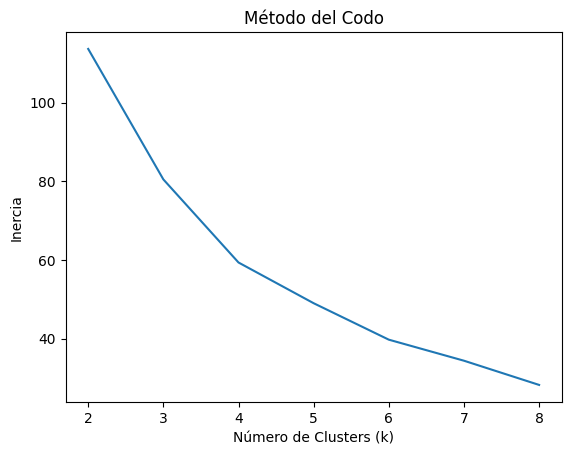

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(factor_scores)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia)
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del Codo")
plt.show()

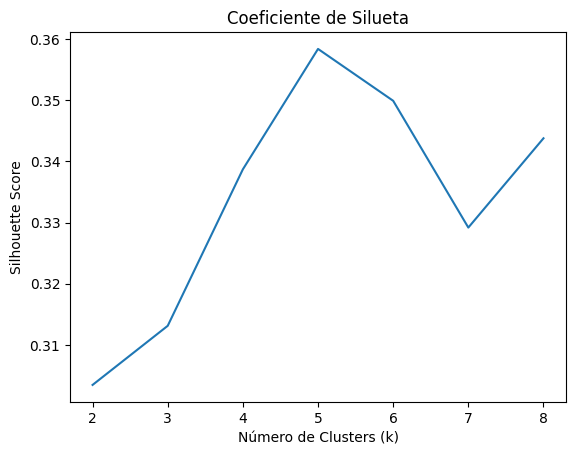

k=2: 0.3035
k=3: 0.3131
k=4: 0.3387
k=5: 0.3583
k=6: 0.3499
k=7: 0.3292
k=8: 0.3438


In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(factor_scores)
    score = silhouette_score(factor_scores, labels)
    silhouette_scores.append(score)

plt.figure()
plt.plot(K_range, silhouette_scores)
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Coeficiente de Silueta")
plt.show()

for k, score in zip(K_range, silhouette_scores):
    print(f"k={k}: {score:.4f}")





## 4.3. Modelo final
- Ajusta el clustering (por ejemplo, **k-means**).
- Asigna a cada cliente un segmento.
- Incluye al menos una visualización (p. ej., dispersión usando 2 factores principales, coloreado por segmento).

**Entrega mínima:**
- Gráfica de codo.
- Gráfica/tabla de silueta.
- Segmentos asignados.
- Visualización de la solución.

Guiandionos por la grafic ade silueta, se determino que el numero adecuado de clusters es 5, cabe destacar que el grafico de codo podria indicar entre 3 y 4 clusters pero se le dio mayor importancia al grafico de silueta

In [ ]:
k_final = 5

kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
factor_scores['Segmento'] = kmeans_final.fit_predict(factor_scores)

factor_scores.head()

,F1,F2,F3,Segmento
0,1.225836,0.048444,-0.546748,2
1,-1.910681,1.098654,1.654203,1
2,-0.177796,1.524867,1.448739,1
3,0.575990,0.495279,1.717356,1
4,0.913582,0.519595,-0.194274,2


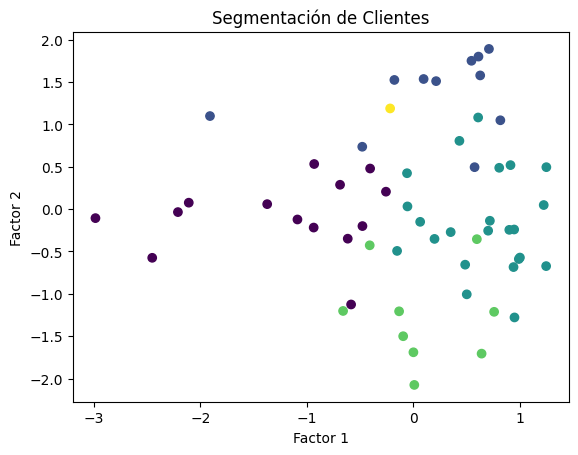

In [ ]:
plt.figure()
plt.scatter(factor_scores['F1'], factor_scores['F2'],
            c=factor_scores['Segmento'])
plt.xlabel("Factor 1")
plt.ylabel("Factor 2")
plt.title("Segmentación de Clientes")
plt.show()

---
# 5. Perfil e interpretación de segmentos
En esta sección debes caracterizar cada segmento.

Incluye:
1. Tabla de **promedios por segmento** (en factores y/o variables originales).
2. Gráficas recomendadas:
   - Heatmap de medias por segmento.
   - Radar plot (opcional).
3. Interpretación en lenguaje de marketing:
   - ¿Qué valora más cada segmento?
   - ¿Qué valora menos?
   - Asigna un **nombre descriptivo** a cada segmento.

**Entrega mínima:**
- Tabla de medias por segmento.
- Interpretación escrita clara para cada segmento.

1. Tabla de **promedios por segmento** (en factores y/o variables originales).

In [ ]:
perfil = factor_scores.groupby("Segmento").mean().round(2)
perfil

,F1,F2,F3
Segmento,,,
0,-1.22,-0.08,-0.34
1,0.15,1.36,1.03
2,0.65,-0.16,-0.49
3,0.08,-1.26,0.88
4,-0.22,1.19,-3.32


2. Gráficas recomendadas:
   - Heatmap de medias por segmento.
   - Radar plot (opcional).

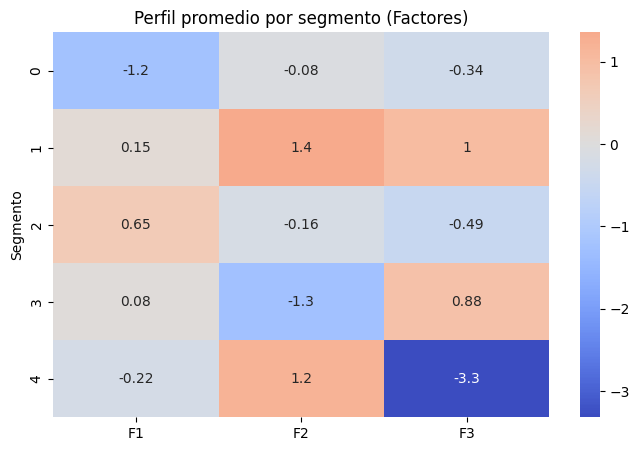

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.heatmap(perfil, annot=True, cmap="coolwarm", center=0)
plt.title("Perfil promedio por segmento (Factores)")
plt.show()

Radar Plot

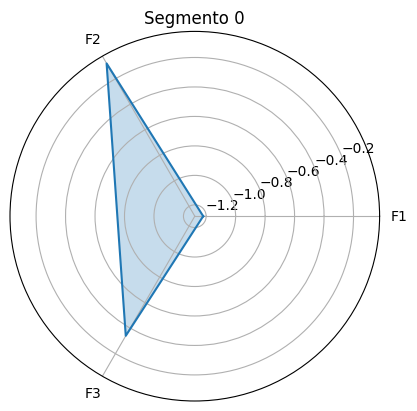

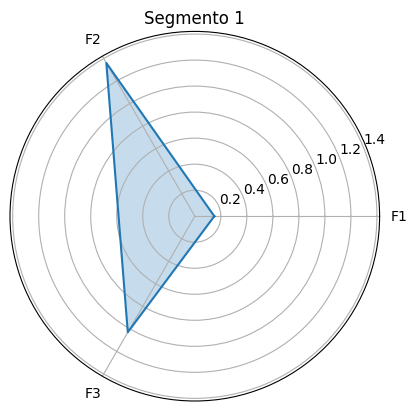

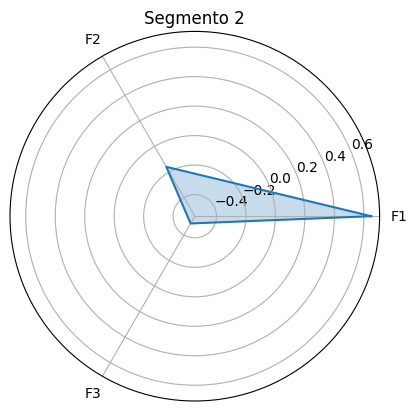

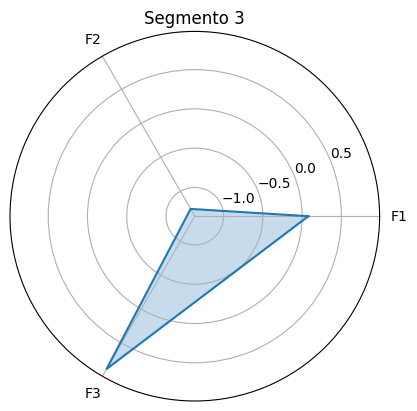

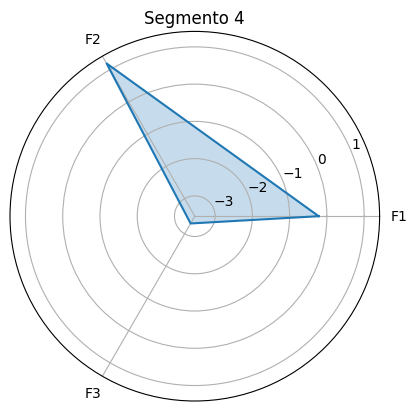

In [ ]:
import numpy as np

labels = perfil.columns
num_vars = len(labels)

angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

for i in perfil.index:
    values = perfil.loc[i].tolist()
    values += values[:1]

    plt.figure()
    plt.polar(angles, values)
    plt.fill(angles, values, alpha=0.25)
    plt.xticks(angles[:-1], labels)
    plt.title(f"Segmento {i}")
    plt.show()

# Interpretación en lenguaje de marketing:
##Segmento 0 **Desinteres**

* Muy bajo en F1 (-1.22)

* Bajo en F3 (-0.34)

* Neutral en F2
* Poco interes en atributos emocionales o funcionales
* baja puntuacion en las medias de la mayoria de dimensiones.

##Implicación estratégica:

* Difíciles de activar

* Requieren estímulos fuertes (precio, promoción)

* Baja prioridad estratégica
### Estos clientes no suelen conectar con el producto, no se recomienda plan de marketing.

##Segmento 1 **Consumidor Habitual**
* Muy alto en F2 (1.36)

* Alto en F3 (1.03)

* Ligeramente positivo en F1

* Valoran varias dimensiones del producto
* Muy activos

###Clientes frecuentes, este segmento consume por si mismo, se recominda ganchos como descuentos en compra al mayoreo.

##Segmento 2 **Comprador Racional**


* Alto en F1 (0.65)

* Bajo en F3 (-0.49)

* Neutral en F2

* Clientes que meditan mucho su compra, observan y comparan varias cualidades de las dimensiones antes de tomar una desicion.

##Clientes que consumen el producto guiandose de muchos factores, se recomienda utilizar las caracteristicas de nuestro producto y compararlo con la competencia en aspectos que seamos mejores.

##Segmento 3 **Emocionales**
* Muy bajo en F2 (-1.26)

* Alto en F3 (0.88)

* Neutral en F1

* Rechazan la dimension f2 y valoran mucho la dimension f3

* Rechazan la tendencia, tienen gustos muy especificos

##Clientes que compran basando en una o mas caracteristocas especificas del producto, se recomienda realizar ofertas en dias epeciales y resatar las caracteristicas de f2.


##Segmento 4 ** Selectivos **

* Alto en F2 (1.19)

* Extremadamente bajo en F3 (-3.32)

* Ligeramente bajo en F1

* Este segmento rechaza la dimension f3 y abraza a  f2
*Puede representar consumidores que desconfían o no conectan con lo que F3 simboliza.

##Se recomienda enfocar f2, identficar el nicho de estos perfiles y usarlo a nuestro favor.

---
# 6. Implicaciones para la estrategia de marketing
Con base en los segmentos identificados:
- Propón **al menos 1 acción** o estrategia de marketing por segmento.
- Justifica por qué es adecuada según los atributos/factores relevantes.

Ejemplos de tipo de acciones (elige según tus resultados):
- Estrategias de precio/promoción
- Mejoras de experiencia en tienda
- Cambios en layout/flujo
- Programas de lealtad
- Servicios adicionales (entrega, pago, etc.)

**Entrega mínima:**
- Lista de acciones por segmento con justificación.

##Segmento Desinteres
Implicación estratégica:

* Difíciles de activar

* Requieren estímulos fuertes (precio, promoción)

* Baja prioridad estratégica

---
# 7. Conclusión
Redacta una conclusión breve (8–12 líneas):
- ¿Qué factores resultaron más interpretables y útiles?
- ¿Qué segmentos fueron más claros?
- ¿Qué decisiones de negocio podrían tomarse con estos resultados?

La segmentacion de mercado es una estrategia muy poderosa par trabajr en conjunto con el area de marketing, podemos identificar fortalezas y debilidades de los productos o servicios que estamos ofreciendo para asi enfocarnos en lo que nos hace mejor que la competencia y tambien permite identificar areas de oportunidad para mejorar nuestra oferta. Tambien se identifican nichos de consumidores para poder enfocar las campañas.
En el lado mas tecnico de la practica, esta nos permite repasar temas fundamentales de la ciencia de datos como lo son el analisis de los datos antes de escoger algun modelo.
Entre lo que mas resalto del conjunto fue la clara tendnecia de os nichos, pues algunos priorizaban ciertas caracteristicas del producto sobre otras, lo cual los guiaba a adquirir o no dicho producto.
El negocio necesita identificar su nicho principal de consumidores, sin descuidar a sus consumidores habituales.

---
## Checklist antes de entregar
- [ ] La libreta corre de inicio a fin sin errores.
- [ ] Incluí justificaciones (estandarización, número de factores, número de clústers).
- [ ] Interpreto factores y segmentos en texto (no solo tablas).
- [ ] Incluí visualizaciones clave.
- [ ] Fijé semilla en procesos aleatorios.